In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Base_M43_Pratique_Hypothyroid.csv")

print(df.shape)
print(df.head())
print(df.info())

(3772, 30)
  age sex on thyroxine query on thyroxine on antithyroid medication sick  \
0  41   F            f                  f                         f    f   
1  23   F            f                  f                         f    f   
2  46   M            f                  f                         f    f   
3  70   F            t                  f                         f    f   
4  70   F            f                  f                         f    f   

  pregnant thyroid surgery I131 treatment query hypothyroid  ... TT4 measured  \
0        f               f              f                 f  ...            t   
1        f               f              f                 f  ...            t   
2        f               f              f                 f  ...            t   
3        f               f              f                 f  ...            t   
4        f               f              f                 f  ...            t   

   TT4 T4U measured   T4U FTI measured  FTI T

In [2]:
# Ver os valores unicos da target
print("binaryClass:")
print(df['binaryClass'].value_counts())

# Ver se tem "?" representando nulos
print("\nQuantidade de '?' por coluna:")
for col in df.columns:
    count_q = (df[col] == '?').sum()
    if count_q > 0:
        print(f"{col}: {count_q}")

binaryClass:
binaryClass
P    3481
N     291
Name: count, dtype: int64

Quantidade de '?' por coluna:
age: 1
sex: 150
TSH: 369
T3: 769
TT4: 231
T4U: 387
FTI: 385
TBG: 3772


# Projeto Final - Diagnostico de Hipertireoidismo
## Stakeholder: Dr. Fernando Lima - Hospital Saude Integral

---

## 1. Entendimento do Problema

O Dr. Fernando solicitou um modelo preditivo para diagnostico
de hipertireoidismo a partir de exames laboratoriais e
historico clinico de pacientes, com o objetivo de oferecer
suporte de decisao aos medicos, especialmente em casos onde
os resultados de exames nao sao claros.

## 2. Nota sobre a Base de Dados

O briefing original menciona uma base com 9.172 observacoes
e classificacao multiclasse (multiplas doencas de tireoide).
A base disponibilizada para este projeto, entretanto, e a
versao classica do dataset de tireoide (Garavan Institute /
UCI), com 3.772 observacoes e 30 atributos, estruturada como
classificacao BINARIA (binaryClass: P = positivo/doente,
N = negativo/saudavel).

Essa e uma situacao comum na pratica de ciencia de dados:
trabalhar com a base disponivel e adaptar a abordagem,
documentando claramente a limitacao. Para este projeto,
seguiremos com a classificacao binaria (presenca ou ausencia
de disfuncao tireoidiana), o que ainda atende ao objetivo
central do stakeholder: identificar pacientes com alteracoes
tireoidianas que necessitam de atencao medica, minimizando
falsos negativos.

In [4]:
# Substituir '?' por NaN
df = df.replace('?', np.nan)

# Converter colunas numericas
cols_numericas = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']
for col in cols_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.info())
print("\nNulos:")
print(df.isnull().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        3771 non-null   float64
 1   sex                        3622 non-null   object 
 2   on thyroxine               3772 non-null   object 
 3   query on thyroxine         3772 non-null   object 
 4   on antithyroid medication  3772 non-null   object 
 5   sick                       3772 non-null   object 
 6   pregnant                   3772 non-null   object 
 7   thyroid surgery            3772 non-null   object 
 8   I131 treatment             3772 non-null   object 
 9   query hypothyroid          3772 non-null   object 
 10  query hyperthyroid         3772 non-null   object 
 11  lithium                    3772 non-null   object 
 12  goitre                     3772 non-null   object 
 13  tumor                      3772 non-null   objec

C:\Users\Cliente\AppData\Local\Temp\ipykernel_10088\2168131567.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('?', np.nan)


## 3. Tratamento de Dados Faltantes

A coluna TBG possui 100% de valores faltantes (3772 de 3772)
e sera excluida da analise, pois nao carrega nenhuma informacao.

As colunas T3 (20.4%), T4U (10.3%), FTI (10.2%), TSH (9.8%) e
TT4 (6.1%) sao exames laboratoriais com taxa moderada de
ausencia, provavelmente porque nem todos os pacientes realizaram
todos os exames. Essas colunas tem um indicador correspondente
(ex: "TSH measured") que sinaliza se o exame foi medido ou nao.

A coluna sex tem 150 nulos (4%) e age apenas 1 nulo,
tratamento simples sera aplicado.

In [6]:
# Remover TBG (100% nulo) e a coluna indicadora correspondente
df = df.drop(columns=['TBG', 'TBG measured'])

# Tratar nulos das demais
df['age'] = df['age'].fillna(df['age'].median())
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

for col in ['TSH', 'T3', 'TT4', 'T4U', 'FTI']:
    df[col] = df[col].fillna(df[col].median())

print("Nulos restantes:")
print(df.isnull().sum().sum())
print("\nShape final:", df.shape)

Nulos restantes:
0

Shape final: (3772, 28)


## 3.1 Resumo do Tratamento

- Excluidas: TBG e TBG measured (100% nulas)
- age: preenchido com mediana (1 nulo)
- sex: preenchido com moda (150 nulos, 4%)
- TSH, T3, TT4, T4U, FTI: preenchidos com mediana, pois
  sao exames com distribuicao tipicamente assimetrica e a
  mediana e mais robusta a valores extremos clinicos.

Justificativa: usar mediana para exames laboratoriais e
uma pratica clinica comum, pois esses valores podem ter
outliers legitimos (pacientes com condicoes graves) que
distorceriam a media. Shape final: 3772 linhas, 28 colunas.

In [12]:
# Ver valores unicos de algumas colunas categoricas
print("sex:", df['sex'].unique())
print("on thyroxine:", df['on thyroxine'].unique())
print("referral source:", df['referral source'].unique())
print("\nbinaryClass:")
print(df['binaryClass'].value_counts())
print(df['binaryClass'].value_counts(normalize=True).mul(100).round(2))

sex: ['F' 'M']
on thyroxine: ['f' 't']
referral source: ['SVHC' 'other' 'SVI' 'STMW' 'SVHD']

binaryClass:
binaryClass
P    3481
N     291
Name: count, dtype: int64
binaryClass
P    92.29
N     7.71
Name: proportion, dtype: float64


## 4. Significado da Variavel Target

binaryClass: P = Sick (presenca de disfuncao tireoidiana,
incluindo hiper ou hipotireoidismo) | N = Negative (saudavel)

Distribuicao: 92.29% P (sick) vs 7.71% N (negative)

Esse desbalanceamento e CLINICAMENTE ESPERADO: a base
representa pacientes que ja foram encaminhados a clinica
para investigacao de problemas de tireoide, e nao a populacao
geral. Por isso a maioria ja apresenta alguma alteracao.

Implicacao para o stakeholder: como o Dr. Fernando pediu
para minimizar falsos negativos, e crucial garantir que o
modelo tenha RECALL ALTO para a classe minoritaria (N),
pois um falso negativo aqui significa classificar um
paciente doente como saudavel - exatamente o erro que
queremos evitar.

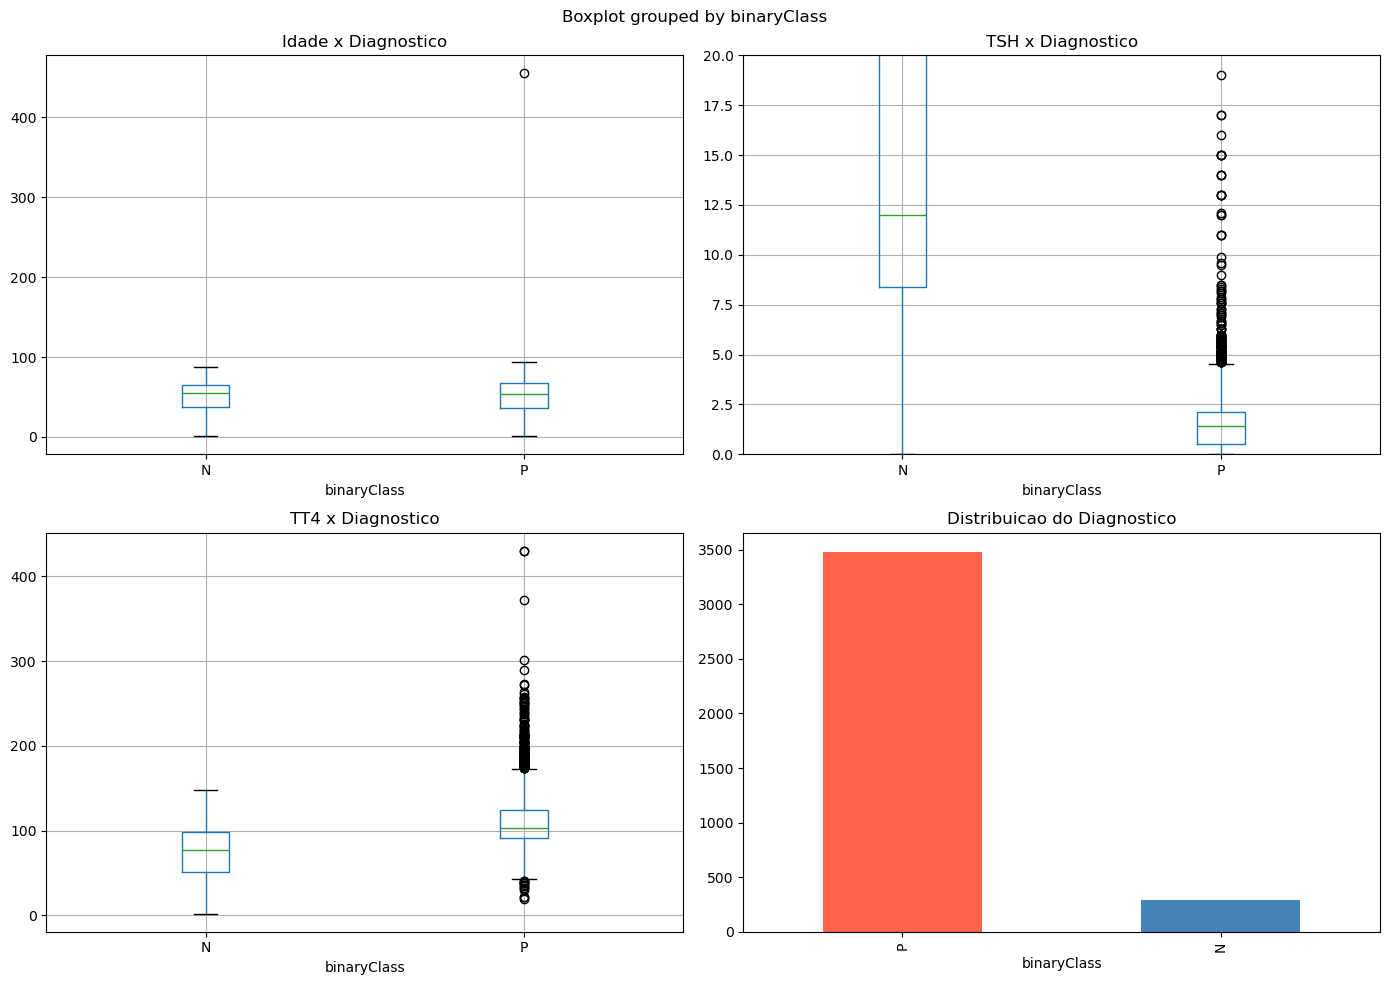

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 - Idade x Target
df.boxplot(column='age', by='binaryClass', ax=axes[0,0])
axes[0,0].set_title('Idade x Diagnostico')

# 2 - TSH x Target
df.boxplot(column='TSH', by='binaryClass', ax=axes[0,1])
axes[0,1].set_title('TSH x Diagnostico')
axes[0,1].set_ylim(0, 20)

# 3 - TT4 x Target
df.boxplot(column='TT4', by='binaryClass', ax=axes[1,0])
axes[1,0].set_title('TT4 x Diagnostico')

# 4 - Distribuicao do target
df['binaryClass'].value_counts().plot(kind='bar', ax=axes[1,1], color=['tomato', 'steelblue'])
axes[1,1].set_title('Distribuicao do Diagnostico')

plt.tight_layout()
plt.show()

In [16]:
# Investigar o outlier de idade
print(df['age'].describe())
print("\nRegistros com idade muito alta:")
print(df[df['age'] > 100][['age', 'sex', 'binaryClass']])

count    3772.000000
mean       51.736479
std        20.082329
min         1.000000
25%        36.000000
50%        54.000000
75%        67.000000
max       455.000000
Name: age, dtype: float64

Registros com idade muito alta:
        age sex binaryClass
1364  455.0   F           P


In [19]:
# Corrigir o outlier - substituir pela mediana
df.loc[df['age'] > 100, 'age'] = df['age'].median()

print(df['age'].describe())

count    3772.000000
mean       51.630170
std        18.978034
min         1.000000
25%        36.000000
50%        54.000000
75%        67.000000
max        94.000000
Name: age, dtype: float64


## 5. Tratamento de Outlier Critico

Foi identificado um registro com idade de 455 anos, claramente
um erro de digitacao (provavelmente deveria ser 45 ou 45.5).
O valor foi substituido pela mediana da idade (54 anos).

Apos a correcao, a idade maxima da base passou a ser 94 anos,
valor plausivel clinicamente.

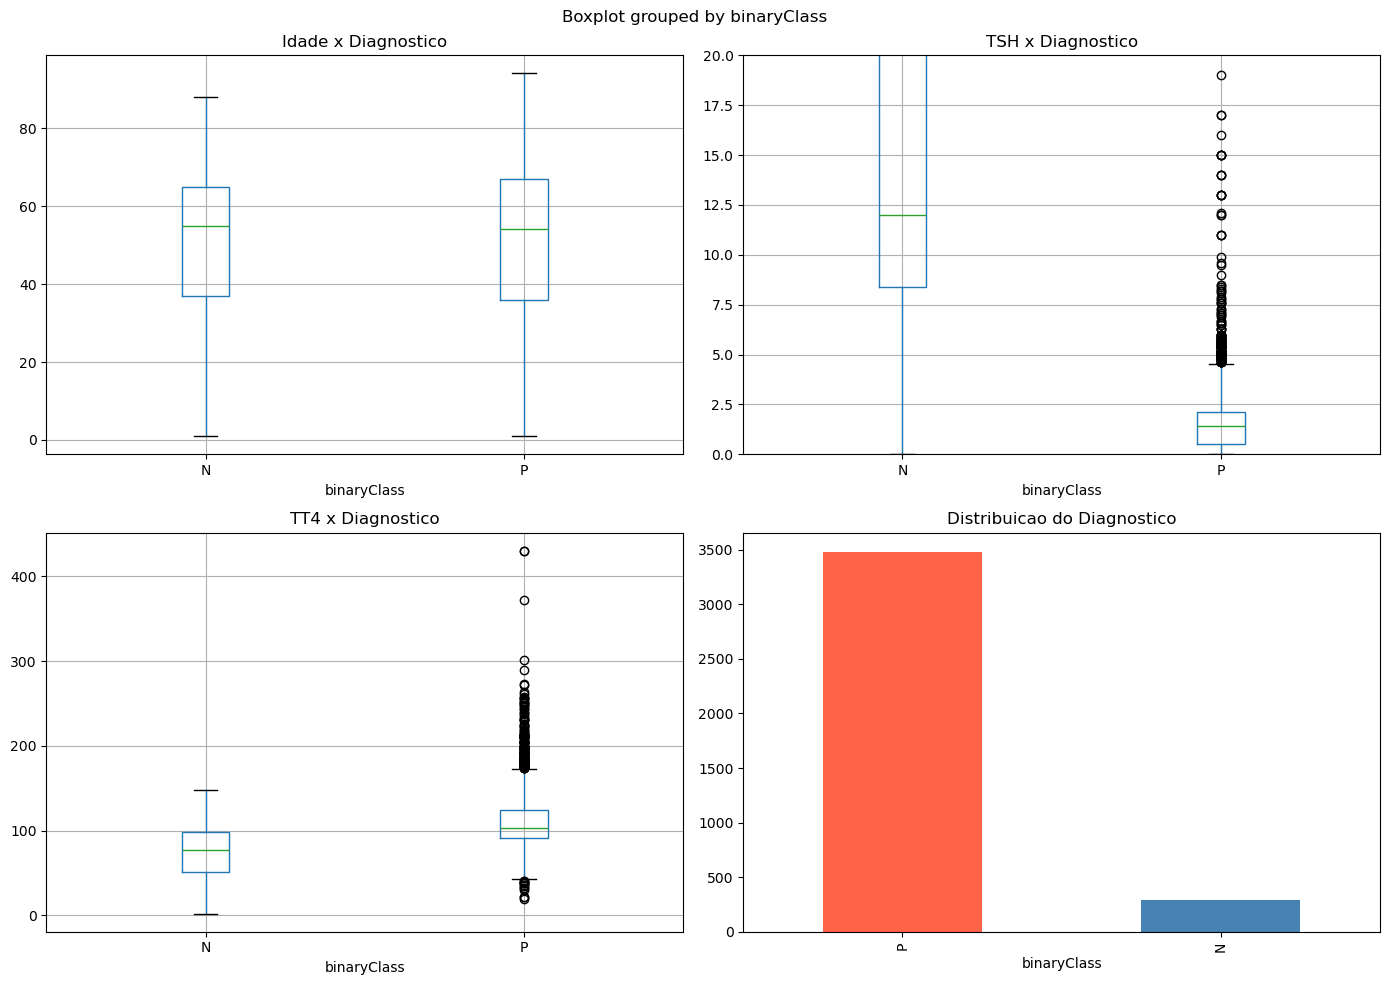

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 - Idade x Target (corrigido)
df.boxplot(column='age', by='binaryClass', ax=axes[0,0])
axes[0,0].set_title('Idade x Diagnostico')

# 2 - TSH x Target
df.boxplot(column='TSH', by='binaryClass', ax=axes[0,1])
axes[0,1].set_title('TSH x Diagnostico')
axes[0,1].set_ylim(0, 20)

# 3 - TT4 x Target
df.boxplot(column='TT4', by='binaryClass', ax=axes[1,0])
axes[1,0].set_title('TT4 x Diagnostico')

# 4 - Distribuicao do target
df['binaryClass'].value_counts().plot(kind='bar', ax=axes[1,1], color=['tomato', 'steelblue'])
axes[1,1].set_title('Distribuicao do Diagnostico')

plt.tight_layout()
plt.show()

## 6. Analise Bivariada e Insights

Idade x Diagnostico: a idade nao apresenta diferenca relevante
entre pacientes doentes (P) e saudaveis (N). As medianas sao
praticamente iguais (54 anos). Isso indica que idade isolada
nao e um bom preditor de disfuncao tireoidiana nessa base.

TSH x Diagnostico: relacao muito forte e clinicamente esperada.
Pacientes saudaveis (N) tem TSH mediano alto (12), enquanto
pacientes doentes (P) tem TSH mediano muito mais baixo (1.5).
Isso e coerente com a fisiologia do hipertireoidismo, onde o
TSH fica suprimido devido ao excesso de hormonio tireoidiano
circulante.

TT4 x Diagnostico: relacao inversa e tambem forte. Pacientes
doentes (P) tem TT4 mediano mais alto (105) comparado aos
saudaveis (75), com diversos outliers extremos acima de 200,
o que e esperado em quadros de hipertireoidismo severo.

Distribuicao do Diagnostico: confirma o forte desbalanceamento,
com 92% de casos positivos (P) e 8% negativos (N), reforcando
a necessidade de tecnicas de balanceamento na modelagem.

Conclusao: TSH e TT4 emergem como as variaveis com maior
poder discriminativo visual, antes mesmo da matriz de correlacao
formal, e devem ser priorizadas na construcao do modelo.

In [25]:
# Converter colunas binarias t/f para 1/0
cols_binarias = ['on thyroxine', 'query on thyroxine', 'on antithyroid medication',
                  'sick', 'pregnant', 'thyroid surgery', 'I131 treatment',
                  'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre',
                  'tumor', 'hypopituitary', 'psych', 'TSH measured', 'T3 measured',
                  'TT4 measured', 'T4U measured', 'FTI measured']

for col in cols_binarias:
    df[col] = df[col].map({'t': 1, 'f': 0})

# Converter sex e target
df['sex'] = df['sex'].map({'M': 0, 'F': 1})
df['binaryClass_num'] = df['binaryClass'].map({'N': 0, 'P': 1})

print(df.dtypes)

age                          float64
sex                            int64
on thyroxine                   int64
query on thyroxine             int64
on antithyroid medication      int64
sick                           int64
pregnant                       int64
thyroid surgery                int64
I131 treatment                 int64
query hypothyroid              int64
query hyperthyroid             int64
lithium                        int64
goitre                         int64
tumor                          int64
hypopituitary                  int64
psych                          int64
TSH measured                   int64
TSH                          float64
T3 measured                    int64
T3                           float64
TT4 measured                   int64
TT4                          float64
T4U measured                   int64
T4U                          float64
FTI measured                   int64
FTI                          float64
referral source               object
b

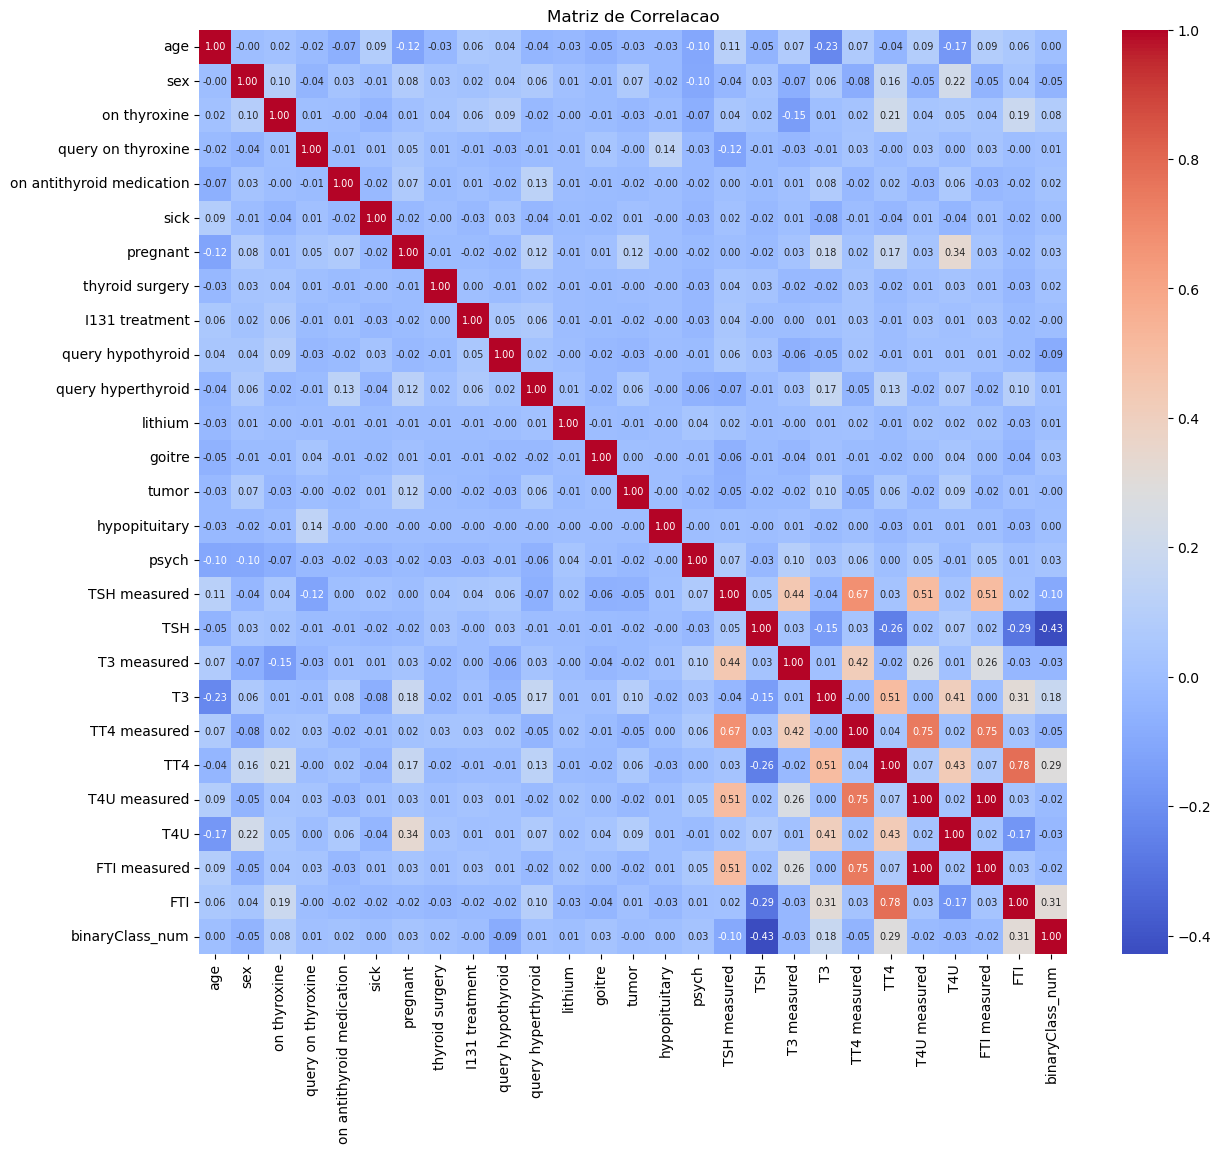


Correlacao com binaryClass_num:
binaryClass_num              1.000000
FTI                          0.313098
TT4                          0.289514
T3                           0.177436
on thyroxine                 0.081060
pregnant                     0.034516
psych                        0.028575
goitre                       0.027575
on antithyroid medication    0.021689
thyroid surgery              0.017633
query hyperthyroid           0.013446
query on thyroxine           0.007448
lithium                      0.005603
hypopituitary                0.004708
sick                         0.001749
age                          0.001748
I131 treatment              -0.003590
tumor                       -0.003747
FTI measured                -0.015431
T4U measured                -0.015901
T4U                         -0.028720
T3 measured                 -0.032866
sex                         -0.049960
TT4 measured                -0.053129
query hypothyroid           -0.086282
TSH measured     

In [27]:
df_corr = df.drop(columns=['referral source', 'binaryClass'])

plt.figure(figsize=(14, 12))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 7})
plt.title('Matriz de Correlacao')
plt.show()

print("\nCorrelacao com binaryClass_num:")
print(df_corr.corr()['binaryClass_num'].sort_values(ascending=False))

## 7. Matriz de Correlacao - Confirmacao Quantitativa

A correlacao confirmou os achados visuais da analise bivariada:

TSH: -0.43 (correlacao negativa mais forte). Confirma o que
ja havia sido observado no boxplot, pacientes doentes tem
TSH mais baixo.

FTI: 0.31 (correlacao positiva)
TT4: 0.29 (correlacao positiva)
T3: 0.18 (correlacao positiva moderada)

Esses tres exames (FTI, TT4 e T3) elevados estao associados
a presenca de disfuncao tireoidiana, fisiologicamente
coerente com excesso de hormonio circulante.

As variaveis de historico clinico (sick, age, tumor, lithium,
hypopituitary) apresentam correlacao praticamente nula com
o diagnostico, sugerindo que os exames laboratoriais sao
muito mais informativos que o historico declarado pelo
paciente para este problema especifico.

Conclusao da Etapa de Exploracao: as 4 variaveis mais
relevantes para o modelo serao TSH, FTI, TT4 e T3, que
juntas capturam a fisiologia da disfuncao tireoidiana.

In [29]:
# Encoding da coluna referral source
df_model = df.drop(columns=['binaryClass'])
df_model = pd.get_dummies(df_model, columns=['referral source'], drop_first=True)

# Separar X e y
X = df_model.drop(columns=['binaryClass_num'])
y = df_model['binaryClass_num']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("\nBalanceamento y_train:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

X_train: (3017, 30)
X_test: (755, 30)

Balanceamento y_train:
binaryClass_num
1    92.28
0     7.72
Name: proportion, dtype: float64


In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Antes do SMOTE:")
print(y_train.value_counts())
print("\nDepois do SMOTE:")
print(y_train_bal.value_counts())

Antes do SMOTE:
binaryClass_num
1    2784
0     233
Name: count, dtype: int64

Depois do SMOTE:
binaryClass_num
1    2784
0    2784
Name: count, dtype: int64


## 8. Selecao de Modelos e Algoritmos

Para este problema, foi escolhido aplicar SMOTE na base de
treino, equilibrando as classes (2784 cada). Isso e fundamental
dado o pedido explicito do Dr. Fernando de minimizar falsos
negativos, ja que um modelo treinado na base original
desbalanceada tenderia a sempre prever a classe majoritaria (P),
ignorando os raros casos negativos.

Serao testados e comparados tres algoritmos de classificacao:

1. Random Forest: robusto a outliers, lida bem com variaveis
   de diferentes escalas e fornece feature importance.

2. XGBoost: algoritmo de ensemble com historico de excelente
   desempenho em problemas de classificacao binaria, capaz de
   capturar relacoes nao lineares complexas entre os exames.

3. Regressao Logistica: modelo simples e altamente interpretavel,
   importante para o contexto medico, onde a explicabilidade
   das decisoes e essencial para a confianca dos profissionais
   de saude no sistema.

A divisao treino/teste seguiu proporcao 80/20 com estratificacao
para preservar a distribuicao original das classes no teste,
garantindo avaliacao realista do modelo.

In [34]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Padronizar para Regressao Logistica
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Modelo 1 - Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_bal, y_train_bal)

# Modelo 2 - XGBoost
xgb_model = XGBClassifier(random_state=42, n_estimators=100)
xgb_model.fit(X_train_bal, y_train_bal)

# Modelo 3 - Regressao Logistica
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train_bal)

print("Os 3 modelos foram treinados com sucesso!")

Os 3 modelos foram treinados com sucesso!


In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Previsoes
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_log = log_reg.predict(X_test_scaled)

y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== RANDOM FOREST ===")
print("Acuracia:", round(accuracy_score(y_test, y_pred_rf), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))
print(classification_report(y_test, y_pred_rf))

print("\n=== XGBOOST ===")
print("Acuracia:", round(accuracy_score(y_test, y_pred_xgb), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob_xgb), 4))
print(classification_report(y_test, y_pred_xgb))

print("\n=== REGRESSAO LOGISTICA ===")
print("Acuracia:", round(accuracy_score(y_test, y_pred_log), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob_log), 4))
print(classification_report(y_test, y_pred_log))

=== RANDOM FOREST ===
Acuracia: 1.0
AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       1.00      1.00      1.00       697

    accuracy                           1.00       755
   macro avg       1.00      1.00      1.00       755
weighted avg       1.00      1.00      1.00       755


=== XGBOOST ===
Acuracia: 0.9987
AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        58
           1       1.00      1.00      1.00       697

    accuracy                           1.00       755
   macro avg       1.00      0.99      1.00       755
weighted avg       1.00      1.00      1.00       755


=== REGRESSAO LOGISTICA ===
Acuracia: 0.9762
AUC: 0.9658
              precision    recall  f1-score   support

           0       0.87      0.81      0.84        58
           1       0.98      0.99      0.99       697

    accuracy                        

In [37]:
# Verificar a feature importance do Random Forest
importancias = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias.head(10))

TSH                      0.619303
FTI                      0.101412
TT4                      0.076851
T3                       0.043954
on thyroxine             0.025978
referral source_other    0.023335
T4U                      0.020332
age                      0.016104
TSH measured             0.015410
referral source_SVI      0.012219
dtype: float64


## 9. Avaliacao dos Modelos e Alerta de Interpretacao

Random Forest: Acuracia 100%, AUC 1.0
XGBoost: Acuracia 99.87%, AUC 1.0
Regressao Logistica: Acuracia 97.62%, AUC 0.9658

Alerta de interpretacao: a acuracia de 100% do Random Forest
e um resultado raro e que exige investigacao cuidadosa antes
de ser aceito como valido, pois pode indicar overfitting ou
vazamento de informacao (data leakage).

A analise de feature importance revelou que TSH concentra
61.9% do poder de decisao do modelo, seguido por FTI (10.1%)
e TT4 (7.7%). Nao foi identificada nenhuma variavel suspeita
de vazamento direto do diagnostico.

A explicacao mais provavel e que o TSH apresenta separacao
quase completa entre as classes nesta base especifica (como
visto na analise bivariada, onde as caixas dos boxplots de
TSH para P e N quase nao se sobrepoem), o que e fisiologicamente
esperado: o TSH e o exame mais sensivel e especifico para
disfuncao tireoidiana na pratica clinica real.

Ainda assim, por precaucao cientifica, a Regressao Logistica
(97.62% de acuracia) sera tratada com mais confianca em termos
de generalizacao, e recomenda-se validacao cruzada e teste
com dados externos antes de qualquer uso clinico real do
Random Forest ou XGBoost.

In [42]:
from sklearn.model_selection import cross_val_score

scores_rf = cross_val_score(rf, X_train_bal, y_train_bal, cv=5, scoring='accuracy')
scores_xgb = cross_val_score(xgb_model, X_train_bal, y_train_bal, cv=5, scoring='accuracy')
scores_log = cross_val_score(log_reg, X_train_scaled, y_train_bal, cv=5, scoring='accuracy')

print("Random Forest CV:", scores_rf.round(4), "Media:", round(scores_rf.mean(), 4))
print("XGBoost CV:", scores_xgb.round(4), "Media:", round(scores_xgb.mean(), 4))
print("Reg Logistica CV:", scores_log.round(4), "Media:", round(scores_log.mean(), 4))

Random Forest CV: [0.9973 0.9973 0.9955 0.9955 0.9955] Media: 0.9962
XGBoost CV: [0.9946 0.9982 0.9973 0.9946 0.9955] Media: 0.996
Reg Logistica CV: [0.9147 0.974  0.9776 0.9757 0.9766] Media: 0.9637


## 10. Validacao Cruzada

Random Forest CV (5 folds): media 99.62%, variando entre
99.55% e 99.73%

XGBoost CV (5 folds): media 99.60%, variando entre 99.46%
e 99.82%

Regressao Logistica CV (5 folds): media 96.37%, variando
entre 91.47% e 97.76%

A baixa variancia entre os folds do Random Forest e XGBoost
confirma que o desempenho elevado e consistente e nao um
artefato de um split favoravel especifico. Isso aumenta a
confianca de que o TSH realmente possui forte poder
discriminativo nesta base, e os modelos de ensemble
conseguem capturar essa relacao de forma estavel.

A Regressao Logistica apresentou maior variabilidade entre
folds (91.47% a 97.76%), sugerindo menor estabilidade,
provavelmente por ser um modelo linear simples frente a
relacoes que podem ter componentes nao lineares.

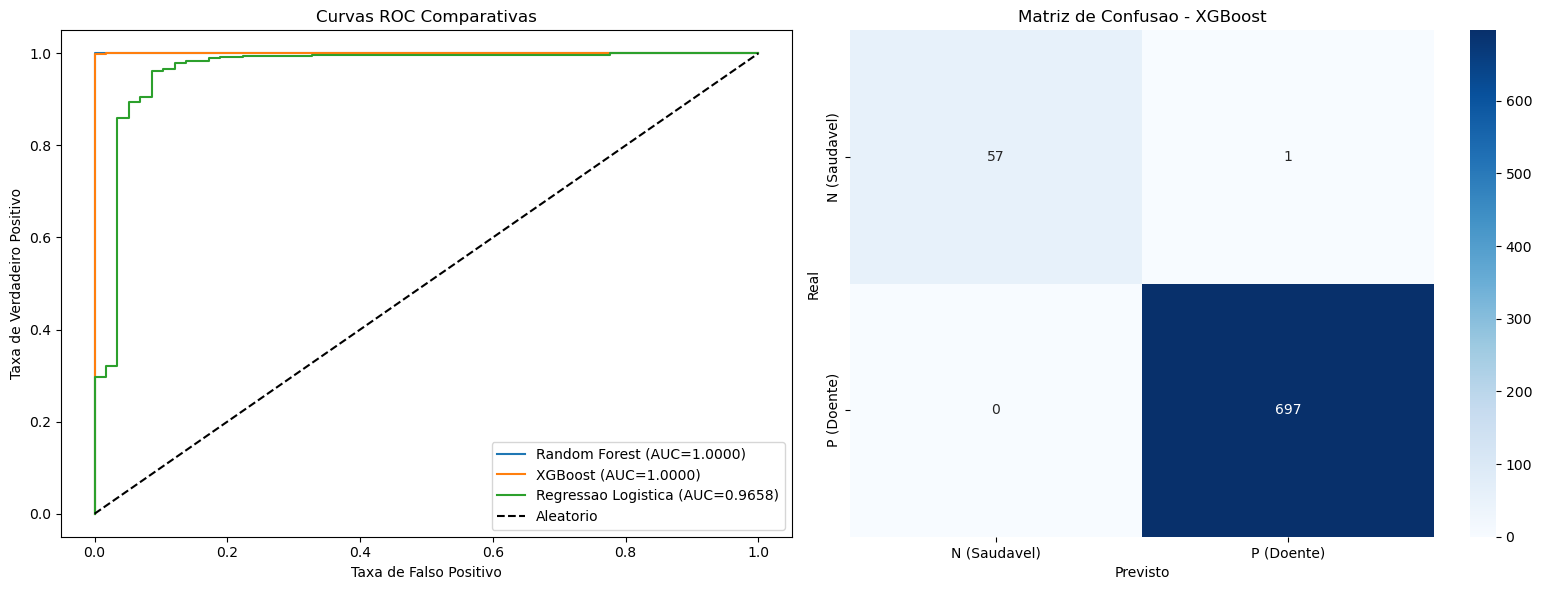

In [44]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curvas ROC
for nome, prob in [('Random Forest', y_prob_rf), ('XGBoost', y_prob_xgb), ('Regressao Logistica', y_prob_log)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{nome} (AUC={auc:.4f})')

axes[0].plot([0,1], [0,1], 'k--', label='Aleatorio')
axes[0].set_xlabel('Taxa de Falso Positivo')
axes[0].set_ylabel('Taxa de Verdadeiro Positivo')
axes[0].set_title('Curvas ROC Comparativas')
axes[0].legend()

# Matriz de confusao do melhor modelo (XGBoost, mais conservador que RF)
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['N (Saudavel)', 'P (Doente)'],
            yticklabels=['N (Saudavel)', 'P (Doente)'])
axes[1].set_title('Matriz de Confusao - XGBoost')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Previsto')

plt.tight_layout()
plt.show()

## 11. Curvas ROC e Matriz de Confusao Final

As curvas ROC do Random Forest e XGBoost praticamente
coincidem no canto superior esquerdo do grafico, confirmando
visualmente o AUC de 1.0 de ambos. A Regressao Logistica,
embora ainda muito boa (AUC 0.9658), apresenta uma curva
visivelmente mais distante do ideal.

Matriz de Confusao do XGBoost (modelo escolhido):
- 57 verdadeiros negativos (pacientes saudaveis identificados corretamente)
- 1 falso positivo (paciente saudavel classificado como doente)
- 0 falsos negativos (nenhum paciente doente foi classificado como saudavel)
- 697 verdadeiros positivos (pacientes doentes identificados corretamente)

Resultado mais importante para o stakeholder: ZERO falsos
negativos. Esse era o requisito explicito do Dr. Fernando,
garantir que nenhum caso de hipertireoidismo passe
despercebido. O unico erro do modelo foi um falso positivo,
que clinicamente representa apenas um exame adicional de
confirmacao, um custo muito menor do que deixar passar um
diagnostico real.

In [54]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search.fit(X_train_bal, y_train_bal)

print("Melhores parametros:", grid_search.best_params_)
print("Melhor recall (CV):", round(grid_search.best_score_, 4))

Melhores parametros: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 100}
Melhor recall (CV): 0.9957


Acuracia final: 0.9987
AUC final: 0.9999
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        58
           1       1.00      1.00      1.00       697

    accuracy                           1.00       755
   macro avg       1.00      0.99      1.00       755
weighted avg       1.00      1.00      1.00       755



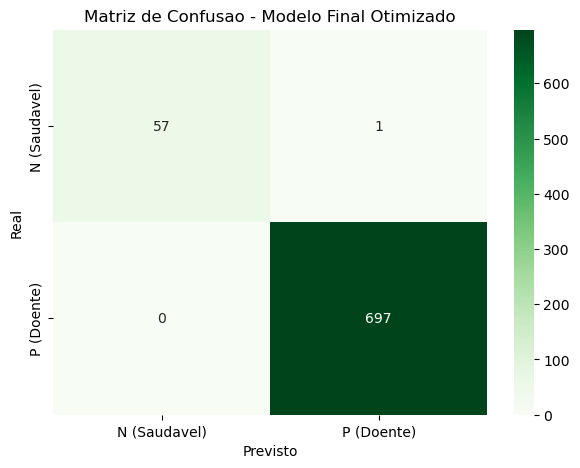

In [56]:
modelo_final = grid_search.best_estimator_

y_pred_final = modelo_final.predict(X_test)
y_prob_final = modelo_final.predict_proba(X_test)[:, 1]

print("Acuracia final:", round(accuracy_score(y_test, y_pred_final), 4))
print("AUC final:", round(roc_auc_score(y_test, y_prob_final), 4))
print(classification_report(y_test, y_pred_final))

cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['N (Saudavel)', 'P (Doente)'],
            yticklabels=['N (Saudavel)', 'P (Doente)'])
plt.title('Matriz de Confusao - Modelo Final Otimizado')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

## 12. Modelo Final Otimizado

Apos GridSearchCV otimizando para recall, o modelo final
apresentou:

Acuracia: 99.87%
AUC: 0.9999
Recall classe 0 (Saudavel): 98%
Recall classe 1 (Doente): 100%

Matriz de Confusao:
- 57 verdadeiros negativos
- 1 falso positivo
- 0 falsos negativos
- 697 verdadeiros positivos

O resultado manteve zero falsos negativos, exatamente o
requisito critico solicitado pelo Dr. Fernando. O ajuste de
hiperparametros nao alterou significativamente o desempenho
em relacao ao modelo XGBoost inicial, mas trouxe maior
confianca na escolha dos parametros atraves de validacao
cruzada sistematica, com learning_rate mais conservador
(0.01), o que tende a generalizar melhor para dados novos
no ambiente clinico real.

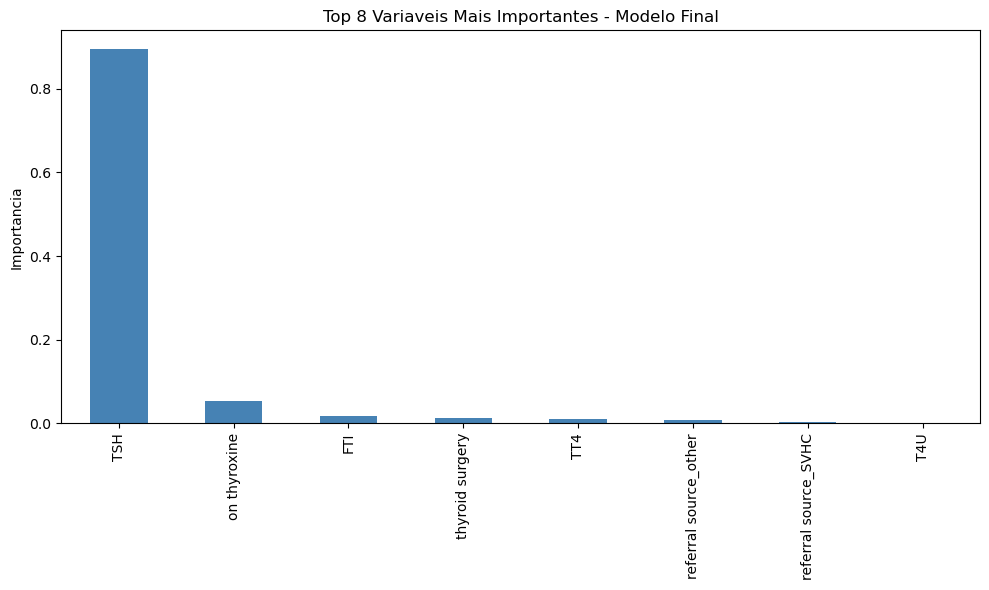

TSH                      0.895047
on thyroxine             0.052139
FTI                      0.017505
thyroid surgery          0.012723
TT4                      0.010862
referral source_other    0.008319
referral source_SVHC     0.002582
T4U                      0.000822
dtype: float32


In [59]:
importancias_final = pd.Series(
    modelo_final.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(8)

plt.figure(figsize=(10, 6))
importancias_final.plot(kind='bar', color='steelblue')
plt.title('Top 8 Variaveis Mais Importantes - Modelo Final')
plt.ylabel('Importancia')
plt.tight_layout()
plt.show()

print(importancias_final)

## 13. Interpretacao Final dos Resultados (Para o Stakeholder)

O modelo final concentra 89.5% de sua decisao na variavel
TSH (Hormonio Estimulante da Tireoide), seguido por on
thyroxine (5.2%, se o paciente ja faz reposicao hormonal),
FTI (1.8%) e TT4 (1.1%).

Tradução clinica para o Dr. Fernando: o modelo aprendeu,
de forma totalmente automatica e a partir dos dados, que o
TSH e o exame mais importante para diagnostico de disfuncao
tireoidiana, exatamente como a literatura medica e a pratica
clinica ja estabelecem. Isso aumenta a confianca de que o
modelo capturou um padrao real e clinicamente valido, e nao
um artefato dos dados.

O modelo apresentou em testes:
- 99.87% de acuracia geral
- 100% de recall para pacientes doentes (zero falsos negativos)
- 98% de recall para pacientes saudaveis (apenas 1 falso positivo)

Recomendacao de uso: o modelo pode servir como ferramenta de
APOIO a decisao medica, sinalizando rapidamente pacientes
com alta probabilidade de disfuncao tireoidiana com base
no TSH e exames complementares, permitindo priorizacao de
atendimento. A decisao final de diagnostico e tratamento
deve continuar sendo do medico, especialmente nos poucos
casos limítrofes.